# Decision Trees

----

In [109]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.tree import export_text, plot_tree, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.inspection import PartialDependenceDisplay

## Examine data and perform additional cleaning

In [74]:
df = pd.read_csv("../data/GamingStudy_data_clean.csv")

# Remove observations missing SPIN_T
df = df[df["SPIN_T"].notna()].copy()

df.head()

,S. No.,Timestamp,GAD1,GAD2,GAD3,GAD4,GAD5,GAD6,GAD7,GADE,...,Birthplace,Residence,Reference,Playstyle,accept,GAD_T,SWL_T,SPIN_T,Residence_ISO3,Birthplace_ISO3
0,1,42052.00437,0,0,0,0,1,0,0,Not difficult at all,...,USA,USA,Reddit,Singleplayer,Accept,1,23,5.0,USA,USA
1,2,42052.00680,1,2,2,2,0,1,0,Somewhat difficult,...,USA,USA,Reddit,Multiplayer - online - with strangers,Accept,8,16,33.0,USA,USA
2,3,42052.03860,0,2,2,0,0,3,1,Not difficult at all,...,Germany,Germany,Reddit,Singleplayer,Accept,8,17,31.0,DEU,DEU
3,4,42052.06804,0,0,0,0,0,0,0,Not difficult at all,...,USA,USA,Reddit,Multiplayer - online - with online acquaintanc...,Accept,0,17,11.0,USA,USA
4,5,42052.08948,2,1,2,2,2,3,2,Very difficult,...,USA,South Korea,Reddit,Multiplayer - online - with strangers,Accept,14,14,13.0,KOR,USA


In [75]:
df.shape

(12813, 55)

In [76]:
df["accept"].value_counts(dropna=False)

accept
Accept    12431
NaN         382
Name: count, dtype: int64

In [77]:
# generate column names to remove
gad_cols = [f"GAD{i}" for i in range(1, 8)]
swl_cols = [f"SWL{i}" for i in range(1, 6)]
spin_cols = [f"SPIN{i}" for i in range(1, 18)]

drop_cols = (
    ["GAD_T", "S. No.", "Timestamp", "Residence_ISO3", "Birthplace_ISO3", "accept", "GADE", "Birthplace", "Residence"]
    + gad_cols
    + swl_cols
    + spin_cols
)

# define target variable
y = df["GAD_T"]

# define feature variables (remove GADE yes or no?) (keep only SPIN_T and SWL_T?)
X = df.drop(columns=drop_cols)

X.head()

,Game,Platform,Hours,earnings,whyplay,League,highestleague,streams,Narcissism,Gender,Age,Work,Degree,Reference,Playstyle,SWL_T,SPIN_T
0,Skyrim,"Console (PS, Xbox, ...)",15.0,I play for fun,having fun,NaN,NaN,0.0,1.0,Male,25,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Singleplayer,23,5.0
1,Other,PC,8.0,I play for fun,having fun,NaN,NaN,2.0,1.0,Male,41,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Multiplayer - online - with strangers,16,33.0
2,Other,PC,0.0,I play for fun,having fun,NaN,NaN,0.0,4.0,Female,32,Employed,Bachelor (or equivalent),Reddit,Singleplayer,17,31.0
3,Other,PC,20.0,I play for fun,improving,NaN,NaN,5.0,2.0,Male,28,Employed,Bachelor (or equivalent),Reddit,Multiplayer - online - with online acquaintanc...,17,11.0
4,Other,"Console (PS, Xbox, ...)",20.0,I play for fun,having fun,NaN,NaN,1.0,1.0,Male,19,Employed,High school diploma (or equivalent),Reddit,Multiplayer - online - with strangers,14,13.0


In [78]:
print(y.unique())
print(y.describe())

[ 1  8  0 14 12 10 19  3  2  4 15  5  6  7 13 11  9 18 16 21 17 20]
count    12813.000000
mean         5.203153
std          4.703894
min          0.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         21.000000
Name: GAD_T, dtype: float64


In [79]:
print(X.describe())

              Hours  highestleague       streams    Narcissism           Age  \
count  12785.000000            0.0  12720.000000  12802.000000  12813.000000   
mean      21.577552            NaN     10.569654      2.028980     20.959494   
std       14.141691            NaN     11.074622      1.061511      3.302994   
min        0.000000            NaN      0.000000      1.000000     18.000000   
25%       12.000000            NaN      4.000000      1.000000     18.000000   
50%       20.000000            NaN      8.000000      2.000000     20.000000   
75%       28.000000            NaN     15.000000      3.000000     22.000000   
max      420.000000            NaN    420.000000      5.000000     56.000000   

              SWL_T        SPIN_T  
count  12813.000000  12813.000000  
mean      19.780223     19.844767  
std        7.233242     13.461298  
min        5.000000      0.000000  
25%       14.000000      9.000000  
50%       20.000000     17.000000  
75%       26.000000     28.

In [80]:
print(X["highestleague"].isnull().sum())
print(len(X))

12813
12813


In [81]:
X["League"].value_counts(dropna=False)

League
NaN                         1781
Gold                         920
Silver                       625
Platinum                     605
Diamond                      519
                            ... 
EU: gold NA: Platinum          1
BRONZE 1 BIIITCH               1
Silver.                        1
Unranked (former gold V)       1
AHGL                           1
Name: count, Length: 1400, dtype: int64

In [82]:
X["League"].value_counts(dropna=False).head(15)

League
NaN          1781
Gold          920
Silver        625
Platinum      605
Diamond       519
gold          302
Unranked      257
Diamond 5     205
silver        199
Gold V        198
Gold 3        191
Gold 1        190
Silver 1      188
Gold 5        180
Silver 2      169
Name: count, dtype: int64

<span style="color:green"> Group each division of each league into single league group. </span>

In [83]:
X["League"] = X["League"].str.lower()

X["League"] = np.select(
    [
        X["League"].str.contains("bronze", na=False),
        X["League"].str.contains("silver", na=False),
        X["League"].str.contains("gold", na=False),
        X["League"].str.contains("plat", na=False),     
        X["League"].str.contains("diamond", na=False),
        X["League"].str.contains("master", na=False),
        X["League"].str.contains("challenger", na=False),
        X["League"].str.contains("unrank", na=False),
        X["League"].isna()
    ],
    [
        "Bronze",
        "Silver",
        "Gold",
        "Platinum",
        "Diamond",
        "Master",
        "Challenger",
        "Unranked",
        "Unknown"
    ],
    default="Other"
)

In [84]:
X["League"].value_counts().head(20)

League
Gold          3072
Platinum      2553
Silver        2212
Unknown       1781
Diamond       1516
Bronze         515
Other          480
Unranked       434
Master         188
Challenger      62
Name: count, dtype: int64

<span style="color:green"> 100% of highestleague column seems to be missing so we remove it. </span>

In [85]:
X = X.drop(columns=["highestleague"])

In [86]:
X.isnull().sum().sort_values(ascending=False)

Degree        1484
streams         93
Work            31
Hours           28
Narcissism      11
Reference       11
Game             0
Platform         0
earnings         0
whyplay          0
League           0
Gender           0
Age              0
Playstyle        0
SWL_T            0
SPIN_T           0
dtype: int64

In [87]:
X["Game"].nunique()

11

In [88]:
X["Game"].value_counts().head(20)

Game
League of Legends      10772
Other                    972
Starcraft 2              325
Counter Strike           300
World of Warcraft        149
Hearthstone               95
Diablo 3                  83
Heroes of the Storm       40
Guild Wars 2              36
Skyrim                    23
Destiny                   18
Name: count, dtype: int64

<span style="color:green"> Replace na with Unknown for Degree, Work, and Reference. </span>

In [89]:
X["Degree"] = X["Degree"].fillna("Unknown")
X["Work"] = X["Work"].fillna("Unknown")
X["Reference"] = X["Reference"].fillna("Unknown")

In [90]:
X.head(20)

,Game,Platform,Hours,earnings,whyplay,League,streams,Narcissism,Gender,Age,Work,Degree,Reference,Playstyle,SWL_T,SPIN_T
0,Skyrim,"Console (PS, Xbox, ...)",15.0,I play for fun,having fun,Unknown,0.0,1.0,Male,25,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Singleplayer,23,5.0
1,Other,PC,8.0,I play for fun,having fun,Unknown,2.0,1.0,Male,41,Unemployed / between jobs,Bachelor (or equivalent),Reddit,Multiplayer - online - with strangers,16,33.0
2,Other,PC,0.0,I play for fun,having fun,Unknown,0.0,4.0,Female,32,Employed,Bachelor (or equivalent),Reddit,Singleplayer,17,31.0
3,Other,PC,20.0,I play for fun,improving,Unknown,5.0,2.0,Male,28,Employed,Bachelor (or equivalent),Reddit,Multiplayer - online - with online acquaintanc...,17,11.0
4,Other,"Console (PS, Xbox, ...)",20.0,I play for fun,having fun,Unknown,1.0,1.0,Male,19,Employed,High school diploma (or equivalent),Reddit,Multiplayer - online - with strangers,14,13.0
5,Other,"Console (PS, Xbox, ...)",4.0,I play for fun,relaxing,Other,0.0,2.0,Male,24,Employed,Bachelor (or equivalent),Reddit,Multiplayer - online - with real life friends,17,13.0
6,Other,PC,30.0,I play for fun,relaxing,Unknown,8.0,2.0,Male,29,Employed,High school diploma (or equivalent),Reddit,Multiplayer - online - with online acquaintanc...,16,26.0
8,Other,"Console (PS, Xbox, ...)",2.0,I play for fun,winning,Unknown,0.0,1.0,Female,23,Employed,Bachelor (or equivalent),Reddit,Multiplayer - online - with strangers,12,55.0
9,World of Warcraft,PC,25.0,I play for fun,improving,Other,0.0,1.0,Female,27,Employed,High school diploma (or equivalent),Reddit,Multiplayer - online - with online acquaintanc...,13,26.0
10,Other,PC,14.0,I play for fun,having fun,Unknown,0.0,1.0,Female,21,Student at college / university,High school diploma (or equivalent),Reddit,Singleplayer,27,6.0


In [91]:
for col in X.select_dtypes(include="object").columns:
    print(f"{col}: {X[col].nunique()}")

Game: 11
Platform: 3
earnings: 298
whyplay: 377
League: 10
Gender: 3
Work: 5
Degree: 5
Reference: 5
Playstyle: 286


In [92]:
pd.set_option("display.max_rows", 50)

display(X["earnings"].value_counts(dropna=False).head(50))
display(X["whyplay"].value_counts(dropna=False).head(50))
display(X["Playstyle"].value_counts(dropna=False).head(50))

earnings
I play for fun                                                                                                                                                     11540
I play mostly for fun but earn a little on the side (tournament winnings, streaming, etc)                                                                            930
I earn a living by playing this game                                                                                                                                  45
I play to win                                                                                                                                                          3
i try                                                                                                                                                                  2
Playing mostly for fun, but have earned a bit in the past (tournaments)                                                                           

whyplay
having fun                                                                           5068
improving                                                                            4685
winning                                                                              1974
relaxing                                                                              620
All of the above                                                                       25
all of the above                                                                       20
Improving and having fun                                                               10
improving and having fun                                                                8
winning and improving                                                                   6
having fun and improving                                                                5
distraction                                                                             3
Wa

Playstyle
Multiplayer - online - with real life friends                                                                                                                5295
Multiplayer - online - with strangers                                                                                                                        3933
Multiplayer - online - with online acquaintances or teammates                                                                                                2520
Singleplayer                                                                                                                                                  727
Multiplayer - offline (people in the same room)                                                                                                                47
all of the above                                                                                                                                                7
All of the above  

In [93]:
X["earnings"] = X["earnings"].str.lower()

X["earnings"] = np.select(
[
    X["earnings"].str.contains("earn a living", na=False),
    X["earnings"].str.contains("earn a little|stream|tournament|side", na=False),
    X["earnings"].str.contains("play for fun", na=False),
    X["earnings"].isna()
],
[
    "Professional",
    "Side Income",
    "Fun",
    "Unknown"
],
default="Other"
)

In [94]:
X["whyplay"] = X["whyplay"].str.lower()

X["whyplay"] = np.select(
[
    X["whyplay"].str.contains("fun", na=False),
    X["whyplay"].str.contains("improv", na=False),
    X["whyplay"].str.contains("win", na=False),
    X["whyplay"].str.contains("relax", na=False),
    X["whyplay"].isna()
],
[
    "Having Fun",
    "Improving",
    "Winning",
    "Relaxing",
    "Unknown"
],
default="Other"
)

In [95]:
X["Playstyle"] = X["Playstyle"].str.lower()

X["Playstyle"] = np.select(
[
    X["Playstyle"].str.contains("singleplayer", na=False),
    X["Playstyle"].str.contains("real life friends", na=False),
    X["Playstyle"].str.contains("strangers", na=False),
    X["Playstyle"].str.contains("acquaintance|teammate", na=False),
    X["Playstyle"].str.contains("offline", na=False),
    X["Playstyle"].isna()
],
[
    "Singleplayer",
    "Real Life Friends",
    "Strangers",
    "Acquaintances",
    "Offline Multiplayer",
    "Unknown"
],
default="Other"
)

In [96]:
for col in X.select_dtypes(include="object").columns:
    print(f"{col}: {X[col].nunique()}")

Game: 11
Platform: 3
earnings: 4
whyplay: 5
League: 10
Gender: 3
Work: 5
Degree: 5
Reference: 5
Playstyle: 6


In [98]:
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)
X_encoded.head()

,Hours,streams,Narcissism,Age,SWL_T,SPIN_T,Game_Destiny,Game_Diablo 3,Game_Guild Wars 2,Game_Hearthstone,...,Degree_Unknown,Reference_Other,Reference_Reddit,Reference_TeamLiquid.net,Reference_Unknown,Playstyle_Offline Multiplayer,Playstyle_Other,Playstyle_Real Life Friends,Playstyle_Singleplayer,Playstyle_Strangers
0,15.0,0.0,1.0,25,23,5.0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
1,8.0,2.0,1.0,41,16,33.0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
2,0.0,0.0,4.0,32,17,31.0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
3,20.0,5.0,2.0,28,17,11.0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,20.0,1.0,1.0,19,14,13.0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1


## Split Data

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y,
    test_size=0.2,
    random_state=1
)

## Modeling

### Decision Tree

In [104]:
# fit decision tree model
tree_gaming_anxiety = DecisionTreeRegressor(random_state = 1)
tree_gaming_anxiety.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_le

In [105]:
tree_summary = export_text(tree_gaming_anxiety, feature_names=X_train.columns.tolist())
print(tree_summary)

|--- SPIN_T <= 27.50
|   |--- SWL_T <= 17.50
|   |   |--- SWL_T <= 11.50
|   |   |   |--- SPIN_T <= 2.50
|   |   |   |   |--- League_Diamond <= 0.50
|   |   |   |   |   |--- streams <= 50.00
|   |   |   |   |   |   |--- Age <= 20.50
|   |   |   |   |   |   |   |--- Hours <= 16.50
|   |   |   |   |   |   |   |   |--- earnings_Side Income <= 0.50
|   |   |   |   |   |   |   |   |   |--- Playstyle_Strangers <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- whyplay_Improving <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- value: [4.00]
|   |   |   |   |   |   |   |   |   |   |--- whyplay_Improving >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- Playstyle_Strangers >  0.50
|   |   |   |   |   |   |   |   |   |   |--- streams <= 11.00
|   |   |   |   |   |   |   |   |   |   |   |--- value: [1.00]
|   |   |   |   |   |   |   |   |   |   |--- streams >  11.00
|   |   |   |   |   |   |   |   |   |   |   |-

In [107]:
importances = pd.DataFrame({'feature_name': X_train.columns, 'importance': tree_gaming_anxiety.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

                feature_name  importance
0                     SPIN_T    0.278756
1                      SWL_T    0.151697
2                      Hours    0.101109
3                    streams    0.080290
4                        Age    0.066691
..                       ...         ...
48  Game_Heroes of the Storm    0.000115
49         Reference_Unknown    0.000114
50          Reference_Reddit    0.000035
51              Game_Destiny    0.000023
52               Game_Skyrim    0.000003

[53 rows x 2 columns]


<span style="color:green"> From the importance table, SPIN_T and SWL_T appear to be the most important predictors. We can also see them at the top of the tree summary. </span>

In [108]:
# Calculate the accuracy of the decision tree on the test data
accuracy = tree_gaming_anxiety.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(accuracy*100))

Accuracy: -42.40%


<span style="color:green"> Accuracy score is -42.40% which means this model is worse than a baseline model that simply predicts the average GAD_T score for all observations. </span>

### Tune Decision Tree

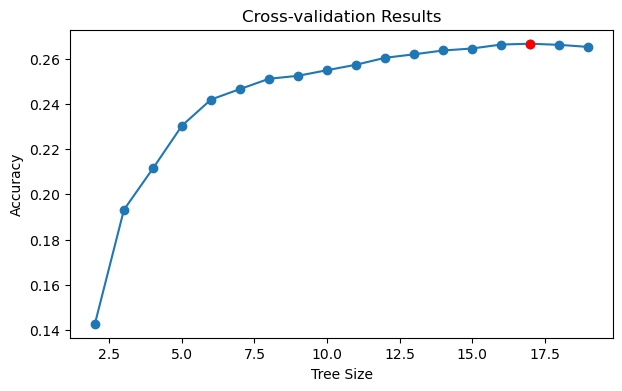

In [110]:
# cross-validation to determine optimal tree size
params = {'max_leaf_nodes': range(2, 20)}  
cv_gaming_anxiety = GridSearchCV(tree_gaming_anxiety, params, cv=20)
cv_gaming_anxiety.fit(X_train, y_train)
cv_results = cv_gaming_anxiety.cv_results_

# find the best score for max leaf nodes
best_size = cv_gaming_anxiety.best_params_['max_leaf_nodes']
best_score = cv_gaming_anxiety.best_score_

# plot results of cross-validation
plt.figure(figsize=(7, 4))
plt.plot(cv_results["param_max_leaf_nodes"].data, cv_results["mean_test_score"], 'o-')
plt.plot(best_size, best_score, 'ro-')
plt.xlabel('Tree Size')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results');

In [111]:
# fit pruned decision tree model
pruned_tree_gaming_anxiety = DecisionTreeRegressor(max_leaf_nodes=best_size, random_state=1)
pruned_tree_gaming_anxiety.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_le

In [112]:
pruned_tree_summary = export_text(pruned_tree_gaming_anxiety, feature_names=X_train.columns.tolist())
print(pruned_tree_summary)

|--- SPIN_T <= 27.50
|   |--- SWL_T <= 17.50
|   |   |--- SWL_T <= 11.50
|   |   |   |--- SPIN_T <= 2.50
|   |   |   |   |--- value: [3.89]
|   |   |   |--- SPIN_T >  2.50
|   |   |   |   |--- value: [7.42]
|   |   |--- SWL_T >  11.50
|   |   |   |--- SPIN_T <= 13.50
|   |   |   |   |--- value: [4.40]
|   |   |   |--- SPIN_T >  13.50
|   |   |   |   |--- Narcissism <= 2.50
|   |   |   |   |   |--- value: [5.47]
|   |   |   |   |--- Narcissism >  2.50
|   |   |   |   |   |--- value: [7.09]
|   |--- SWL_T >  17.50
|   |   |--- SPIN_T <= 15.50
|   |   |   |--- SWL_T <= 24.50
|   |   |   |   |--- value: [3.27]
|   |   |   |--- SWL_T >  24.50
|   |   |   |   |--- value: [2.34]
|   |   |--- SPIN_T >  15.50
|   |   |   |--- SWL_T <= 23.50
|   |   |   |   |--- value: [4.71]
|   |   |   |--- SWL_T >  23.50
|   |   |   |   |--- value: [3.71]
|--- SPIN_T >  27.50
|   |--- SPIN_T <= 43.50
|   |   |--- SWL_T <= 12.50
|   |   |   |--- Hours <= 75.00
|   |   |   |   |--- value: [9.25]
|   |   |   |--

In [113]:
# Calculate the accuracy of the decision tree on the test data
accuracy_pruned = pruned_tree_gaming_anxiety.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(accuracy_pruned*100))

Accuracy: 26.49%


### Random Forest Tuning

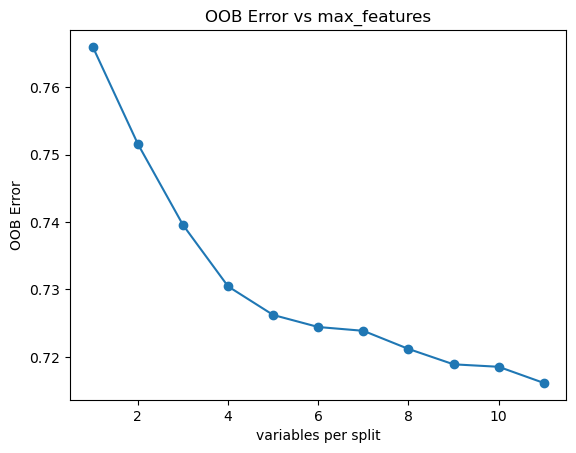

In [101]:
# Create plot to find optimal max_features
rf_gaming_anxiety = RandomForestRegressor(n_estimators=200, oob_score=True, random_state=1)
oob_errors = []

for n in range(1, 12):
    rf_gaming_anxiety.set_params(max_features=n)
    
    rf_gaming_anxiety.fit(X_train, y_train)
    oob_error = 1 - rf_gaming_anxiety.oob_score_
    oob_errors.append(oob_error)

# plot error vs max_features
plt.plot(range(1, 12), oob_errors, marker='o')
plt.xlabel("variables per split")
plt.ylabel("OOB Error")
plt.title("OOB Error vs max_features")
plt.show()